In [2]:
import os

# Cambia esto por la ruta de tu carpeta si el script no está dentro de ella
carpeta = 'Users\manri\OneDrive\Documents\Beta' 

# Filtramos solo las imágenes y las ordenamos
archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
archivos.sort()

for i, archivo in enumerate(archivos, start=1):
    extension = os.path.splitext(archivo)[1]
    nuevo_nombre = f"{i}{extension}"
    
    ruta_vieja = os.path.join(carpeta, archivo)
    ruta_nueva = os.path.join(carpeta, nuevo_nombre)
    
    os.rename(ruta_vieja, ruta_nueva)

print("¡Listo! Todas las fotos han sido renombradas.")

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\manri\AppData\Local\Temp\ipykernel_16164\2302870787.py:4: SyntaxWarning: invalid escape sequence '\m'
  carpeta = 'Users\manri\OneDrive\Documents\Beta'
C:\Users\manri\AppData\Local\Temp\ipykernel_16164\2302870787.py:4: SyntaxWarning: invalid escape sequence '\m'
  carpeta = 'Users\manri\OneDrive\Documents\Beta'


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Users\\manri\\OneDrive\\Documents\\Beta'

Constante de atenuación (alpha): 9.1975 Np/m
Constante de fase (beta): 47.7585 rad/m


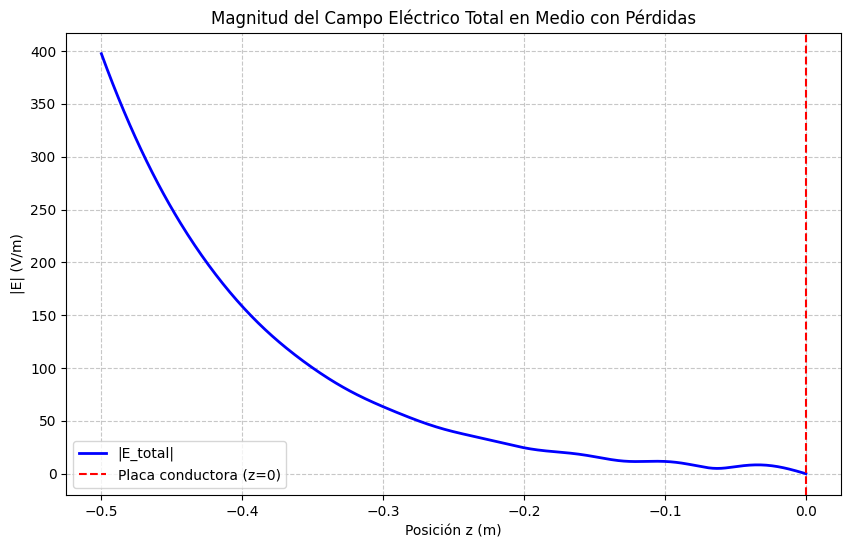

El campo reflejado en z < 0 es: -4.0 * exp(9.1975+47.7585j * z) V/m


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parámetros del Problema ---
f = 1.0e9                     # Frecuencia: 1.0 GHz
omega = 2 * np.pi * f         # Frecuencia angular
epsilon_0 = 8.85418782e-12    # Permitividad del vacío
mu_0 = 4 * np.pi * 1e-7       # Permeabilidad del vacío

# Medio: epsilon = (5 - j2)*epsilon_0, mu = mu_0
epsilon_complex = (5 - 2j) * epsilon_0
mu = mu_0

# Campo incidente en z=0
E0_plus = 4.0  # V/m

# --- 2. Cálculos de Propagación ---
# Constante de propagación gamma = sqrt(j * omega * mu * (sigma + j * omega * epsilon))
# Para un dieléctrico con pérdidas: gamma = j * omega * sqrt(mu * epsilon_complex)
gamma = 1j * omega * np.sqrt(mu * epsilon_complex)
alpha = np.real(gamma)
beta = np.imag(gamma)

print(f"Constante de atenuación (alpha): {alpha:.4f} Np/m")
print(f"Constante de fase (beta): {beta:.4f} rad/m")

# --- 3. Reflexión en Conductor Perfecto (z=0) ---
# En un conductor perfecto, el campo eléctrico total en la interfaz es cero:
# E_total(0) = E_inc(0) + E_ref(0) = 0  => E_ref(0) = -E_inc(0)
E0_minus = -E0_plus

# --- 4. Definición de los Campos ---
# Suponiendo propagación en +z para la incidente (hacia la placa)
# y en -z para la reflejada (alejándose de la placa).
# Nota: El enunciado dice z < 0 para el medio, por lo que la onda incidente
# viaja hacia la derecha (+z) y choca en z=0.

z = np.linspace(-0.5, 0, 500)

# E_inc = E0_plus * exp(-gamma * z)  --> viaja en +z
# E_ref = E0_minus * exp(gamma * z)   --> viaja en -z
E_inc = E0_plus * np.exp(-gamma * z)
E_ref = E0_minus * np.exp(gamma * z)
E_total = E_inc + E_ref

# --- 5. Graficar ---
plt.figure(figsize=(10, 6))
plt.plot(z, np.abs(E_total), label='|E_total|', color='blue', linewidth=2)
plt.axvline(x=0, color='red', linestyle='--', label='Placa conductora (z=0)')

plt.title('Magnitud del Campo Eléctrico Total en Medio con Pérdidas')
plt.xlabel('Posición z (m)')
plt.ylabel('|E| (V/m)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"El campo reflejado en z < 0 es: {E0_minus} * exp({gamma:.4f} * z) V/m")

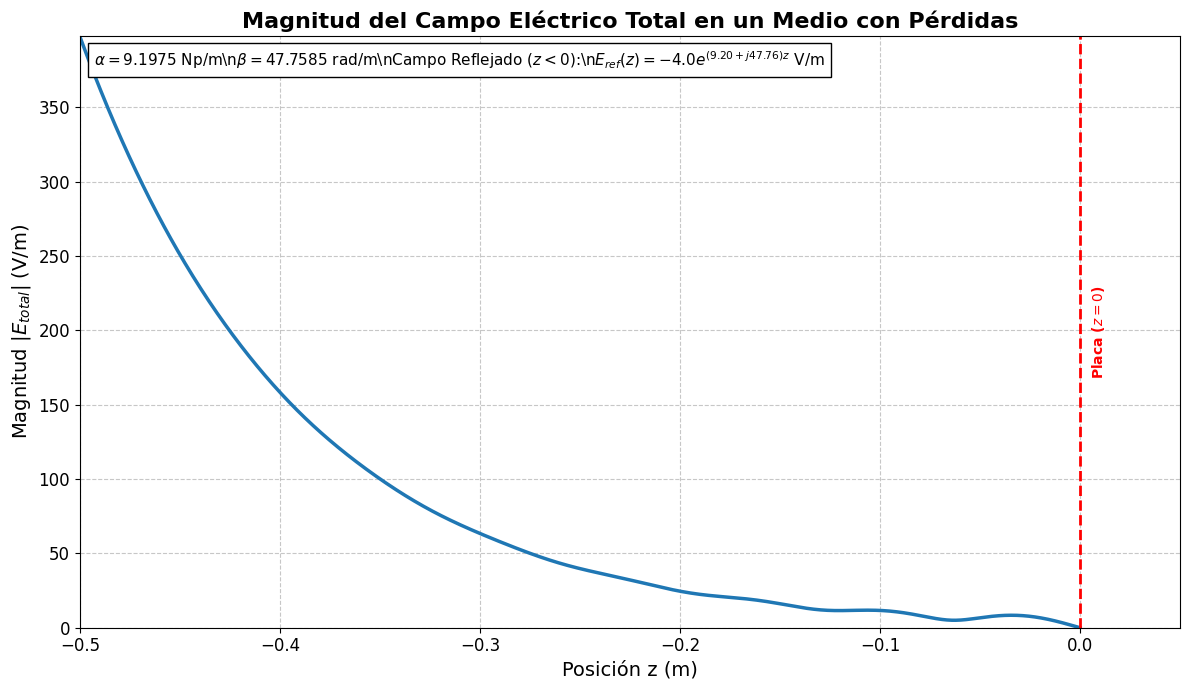

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# --- 1. Parámetros del Problema ---
E0_incident_amp = 4.0      # Amplitud del campo incidente en z=0 (V/m)
f = 1.0e9                     # Frecuencia: 1.0 GHz (Hz)
omega = 2 * np.pi * f         # Frecuencia angular (rad/s)
epsilon_0 = 8.85418782e-12    # Permitividad del vacío (F/m)
mu_0 = 4 * np.pi * 1e-7       # Permeabilidad del vacío (H/m)

# Propiedades del Medio (Lossy Dielectric): eps = (5 - j2)*eps0, mu = mu0
epsilon_r_complex = 5 - 2j
epsilon_complex = epsilon_r_complex * epsilon_0
mu = mu_0

# --- 2. Cálculos de Propagación ---
# Constante de propagación compleja gamma = alpha + j*beta
# gamma = j * omega * sqrt(mu * epsilon_complex)
gamma = 1j * omega * np.sqrt(mu * epsilon_complex)
alpha = np.real(gamma)        # Constante de atenuación (Np/m)
beta = np.imag(gamma)         # Constante de fase (rad/m)

# --- 3. Reflexión en el Conductor Perfecto (PEC) a z=0 ---
# La condición de frontera en un PEC es Etan_total = 0.
# E_inc(0) + E_ref(0) = 0  =>  E_ref(0) = -E_inc(0)
# El coeficiente de reflexión es Gamma = -1.
E0_reflected_amp = -E0_incident_amp

# Expresión matemática del campo reflejado:
# E_ref(z) = E0_reflected_amp * exp(gamma * z)
# (Propagándose en la dirección -z, alejándose de la placa)
ref_field_str = rf"$E_{{ref}}(z) = {E0_reflected_amp:.1f} e^{{({alpha:.2f} + j{beta:.2f})z}}$ V/m"

# --- 4. Definición del Rango Espacial y Cálculo del Campo Total ---
# Rango solicitado: -0.5 <= z <= 0
z = np.linspace(-0.5, 0, 1000)

# Para usar tu fórmula elegante, necesitamos d = distancia positiva desde la placa
d = -z

# Magnitud del campo eléctrico total usando la identidad de la onda estacionaria con pérdidas
E_total_mag = 2 * E0_incident_amp * np.sqrt(np.sinh(alpha * d)**2 + np.sin(beta * d)**2)

# --- 5. Graficar ---
fig, ax = plt.subplots(figsize=(12, 7))

# Trazar la magnitud del campo total
ax.plot(z, E_total_mag, label=r'$|E_{total}(z)|$', color='#1f77b4', linewidth=2.5)

# Añadir la línea de la placa conductora en z=0
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Placa Conductora Perfecta')
ax.text(0.005, E_total_mag.max()*0.5, 'Placa ($z=0$)', color='red', rotation=90, va='center', fontweight='bold')

# --- 6. Crear el recuadro de texto con los valores ---
text_content = (
    rf"$\alpha = {alpha:.4f}$ Np/m\n"
    rf"$\beta = {beta:.4f}$ rad/m\n"
    r"Campo Reflejado ($z < 0$):\n"
    rf"{ref_field_str}"
)

# Usar AnchoredText para colocar el cuadro de forma ordenada
# loc=2 coloca el cuadro en la esquina superior izquierda (dentro de los ejes)
anchored_text = AnchoredText(text_content, loc=2, prop=dict(size=11), frameon=True)
ax.add_artist(anchored_text)

# Mejorar el formato de la gráfica
ax.set_title('Magnitud del Campo Eléctrico Total en un Medio con Pérdidas', fontsize=16, fontweight='bold')
ax.set_xlabel('Posición z (m)', fontsize=14)
ax.set_ylabel(r'Magnitud $|E_{total}|$ (V/m)', fontsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_xlim(-0.5, 0.05) # Un poco de margen a la derecha para la etiqueta
ax.set_ylim(0, np.ceil(E_total_mag.max())) # Ajuste dinámico del eje Y
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

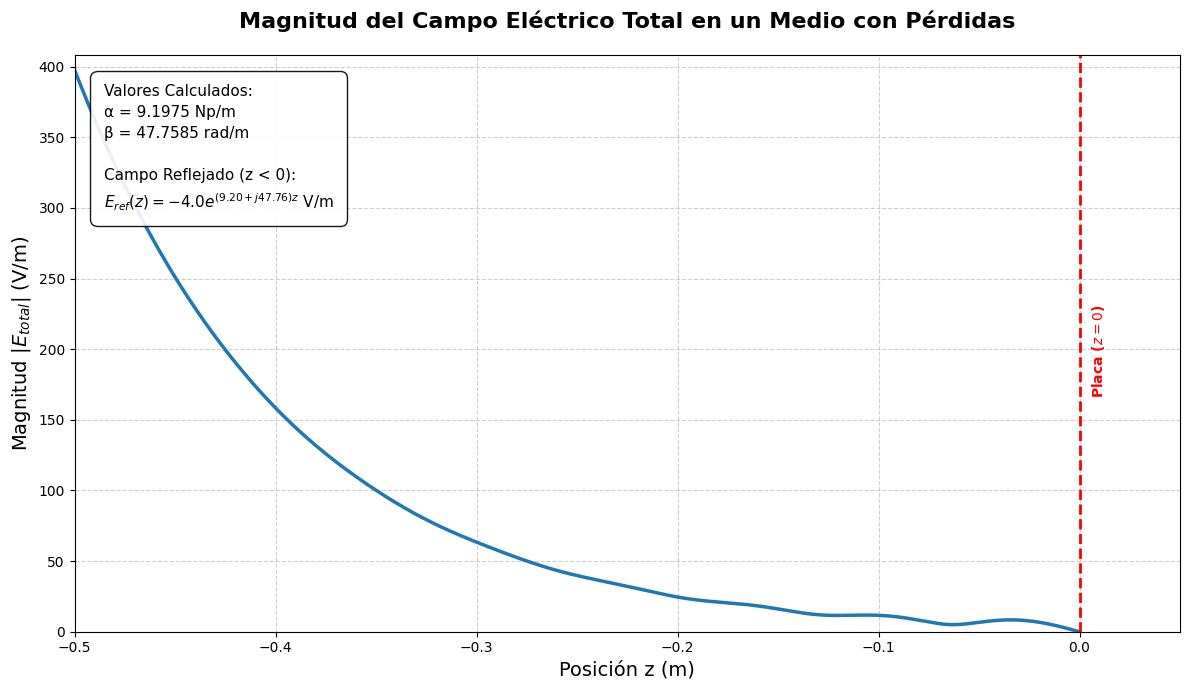

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# --- 1. Parámetros y Cálculos (Igual que antes) ---
E0 = 4.0
f = 1e9
omega = 2 * np.pi * f
epsilon_0 = 8.85418782e-12
mu_0 = 4 * np.pi * 1e-7

epsilon_r = 5 - 2j
gamma = 1j * omega * np.sqrt(mu_0 * epsilon_r * epsilon_0)
alpha = np.real(gamma)
beta = np.imag(gamma)

z = np.linspace(-0.5, 0, 1000)
d = -z
E_total_mag = 2 * E0 * np.sqrt(np.sinh(alpha * d)**2 + np.sin(beta * d)**2)

# --- 2. Preparar el Texto del Recuadro ---
# Usamos saltos de línea reales y f-strings limpios
info_text = (
    f"Valores Calculados:\n"
    f"α = {alpha:.4f} Np/m\n"
    f"β = {beta:.4f} rad/m\n\n"
    f"Campo Reflejado (z < 0):\n"
    f"$E_{{ref}}(z) = -4.0 e^{{({alpha:.2f} + j{beta:.2f})z}}$ V/m"
)

# --- 3. Graficar ---
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(z, E_total_mag, label=r'$|E_{total}(z)|$', color='#1f77b4', linewidth=2.5)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.text(0.005, E_total_mag.max()*0.5, 'Placa ($z=0$)', color='red', rotation=90, va='center', fontweight='bold')

# --- 4. Configuración Estética del Recuadro ---
# 'prop' controla la fuente, 'frameon' el borde, y manejamos el padding
anchored_text = AnchoredText(
    info_text, 
    loc='upper left', 
    prop=dict(size=11, linespacing=1.5), # Aumentamos el interlineado
    frameon=True,
    borderpad=1.5 # Espacio entre el texto y el borde del cuadro
)

# Ajustar el estilo del cuadro (fondo blanco con ligera transparencia)
anchored_text.patch.set_boxstyle("round,pad=0.5")
anchored_text.patch.set_facecolor("white")
anchored_text.patch.set_alpha(0.9)
anchored_text.patch.set_edgecolor("black")

ax.add_artist(anchored_text)

# Formato final
ax.set_title('Magnitud del Campo Eléctrico Total en un Medio con Pérdidas', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Posición z (m)', fontsize=14)
ax.set_ylabel(r'Magnitud $|E_{total}|$ (V/m)', fontsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_xlim(-0.5, 0.05)
ax.set_ylim(0, np.ceil(E_total_mag.max()) + 10)

plt.tight_layout()
plt.show()

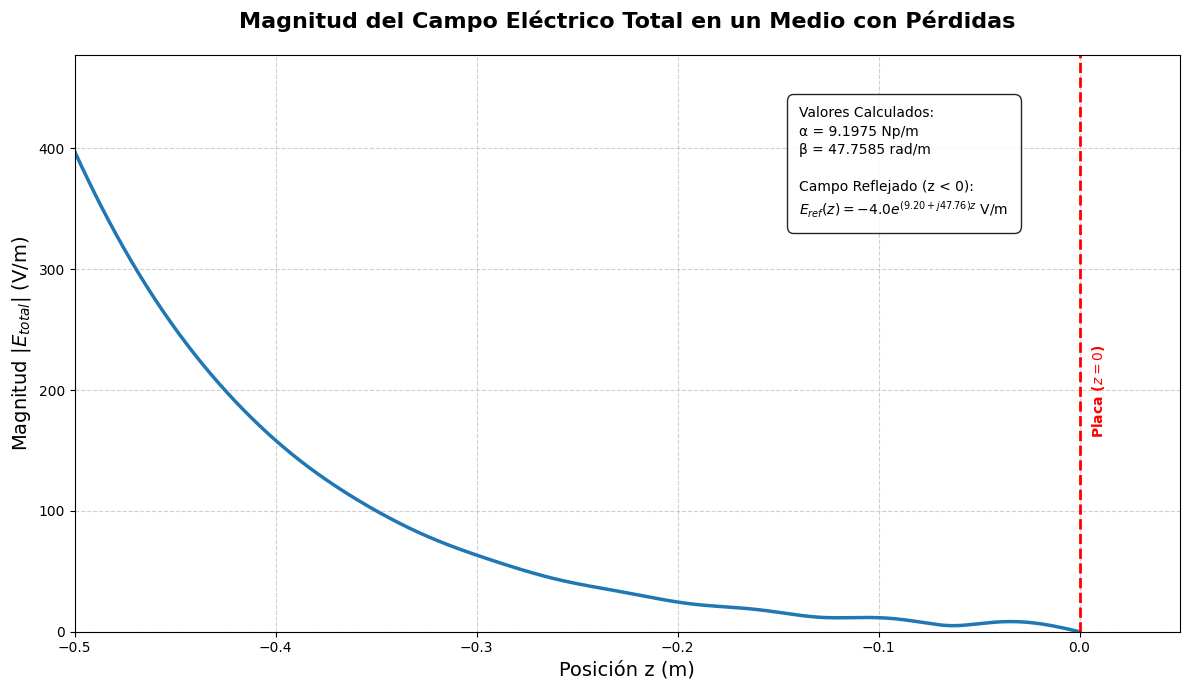

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText


E0 = 4.0
f = 1e9
omega = 2 * np.pi * f
epsilon_0 = 8.85418782e-12
mu_0 = 4 * np.pi * 1e-7

epsilon_r = 5 - 2j
gamma = 1j * omega * np.sqrt(mu_0 * epsilon_r * epsilon_0)
alpha = np.real(gamma)
beta = np.imag(gamma)

z = np.linspace(-0.5, 0, 1000)
d = -z
E_total_mag = 2 * E0 * np.sqrt(np.sinh(alpha * d)**2 + np.sin(beta * d)**2)


info_text = (
    f"Valores Calculados:\n"
    f"α = {alpha:.4f} Np/m\n"
    f"β = {beta:.4f} rad/m\n\n"
    f"Campo Reflejado (z < 0):\n"
    f"$E_{{ref}}(z) = -4.0 e^{{({alpha:.2f} + j{beta:.2f})z}}$ V/m"
)


fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(z, E_total_mag, label=r'$|E_{total}(z)|$', color='#1f77b4', linewidth=2.5)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.text(0.005, E_total_mag.max()*0.5, 'Placa ($z=0$)', color='red', rotation=90, va='center', fontweight='bold')


anchored_text = AnchoredText(
    info_text, 
    loc='upper center', 
    prop=dict(size=10, linespacing=1.4),
    frameon=True,
    borderpad=1.2,
    bbox_to_anchor=(0.75, 0.95), 
    bbox_transform=ax.transAxes
)

anchored_text.patch.set_boxstyle("round,pad=0.5")
anchored_text.patch.set_facecolor("white")
anchored_text.patch.set_alpha(0.85)
anchored_text.patch.set_edgecolor("black")

ax.add_artist(anchored_text)

ax.set_title('Magnitud del Campo Eléctrico Total en un Medio con Pérdidas', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Posición z (m)', fontsize=14)
ax.set_ylabel(r'Magnitud $|E_{total}|$ (V/m)', fontsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.6)


ax.set_ylim(0, E_total_mag.max() * 1.2) 
ax.set_xlim(-0.5, 0.05)

plt.tight_layout()
plt.show()